## My Excersise Notes ##

This exercise is about rendering histogram vizualisations for the Number of Apples for sale at each **Spend-n-Save** store, alongside learning about how to calculate probabilities from the histograms themselves.

### Load the data ###

In [1]:
import pandas as pd # to import data into a dataframe
import seaborn as sns # to draw a histogram and have it look somewhat nice
import numpy as np # to determine bin sizes and help make things reproduceable
import statistics # to calculate mean and SD

Matplotlib is building the font cache; this may take a moment.


In [4]:
## First, use pd.read_csv() to read the data in "spend_n_save.txt"
spend_n_save_df = pd.read_csv("/Users/albertadlersson/Desktop/Mina Skrivbordsfiler/4. Utbilding/5. Python Learning - 2026/StatQuest Exercises/My Attempts/Ch_02 - 31 jul/spend_n_save.txt", sep="\t")

# Verify taht read_csv() was successful by printing out the first few rows
spend_n_save_df.head()

## rename num.apples to num_apples so it's easier to access the values
spend_n_save_df.rename(columns={'num.apples': 'num_apples'}, inplace=True)

## print out first few rows to verify the name
spend_n_save_df.head()

,id,num_apples
0,1,27
1,2,17
2,3,22
3,4,23
4,5,22


### Build the histograms ###

<Axes: xlabel='num_apples', ylabel='Count'>

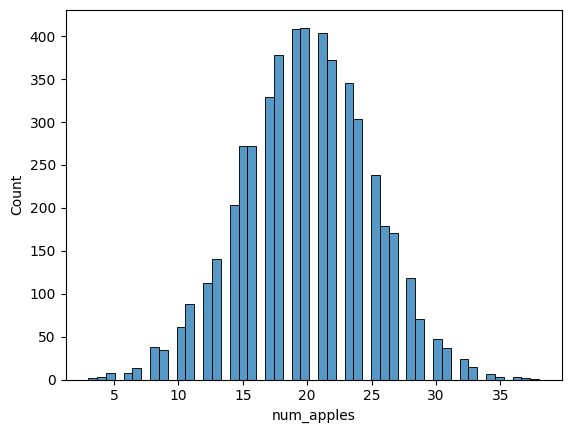

In [5]:
## using the default method for finding optimal bins
sns.histplot(data=spend_n_save_df, x='num_apples')

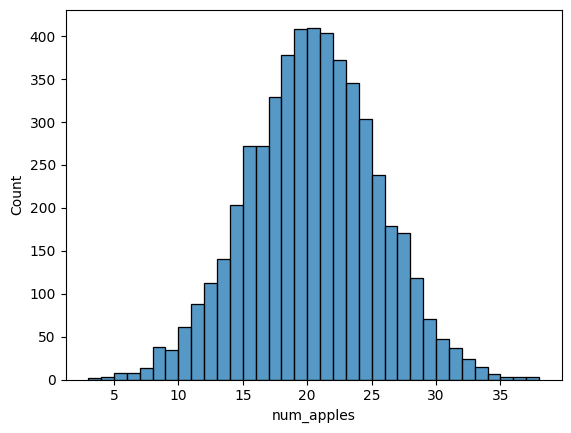

In [6]:
## Calculate bin edges using a specific rule by setting the 'bins' parameter
## Other options 'sturges', 'sqrt', and several more.
my_hist = sns.histplot(data=spend_n_save_df, x='num_apples', bins='scott')

### Save the histogram as a PDF ###

In [7]:
## Extract the figure from our histogram
fig = my_hist.get_figure()

## Save the figure as a PDF-file
fig.savefig('spend_n_save_histogram.pdf')

### Manually change the bin sizes ###

<Axes: xlabel='num_apples', ylabel='Count'>

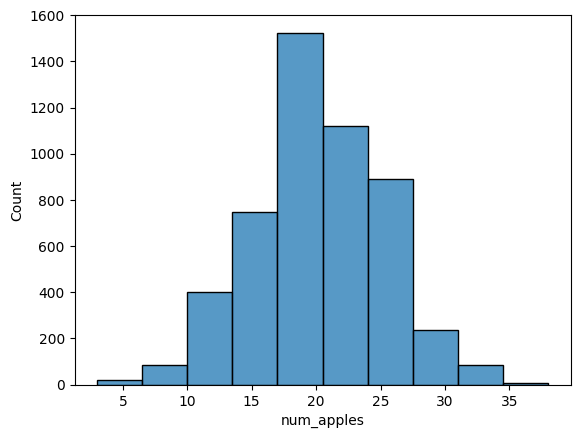

In [10]:
sns.histplot(data=spend_n_save_df, x='num_apples', bins=10)

### Calculating Probabilities from the Data

In [11]:
## Count the number of rows in the dataset where num_apples >= 32
num_stores = (spend_n_save_df['num_apples'] >= 32).sum()

## Now, print out the number of rows
print(f"The number of rows with num_apples >= 32: {num_stores}")

The number of rows with num_apples >= 32: 55


In [12]:
## Now, we just divide `num_stores` with the total numbers of rows in the data set
## to get the probability of num_apples >= 32
prob_frac = num_stores / len(spend_n_save_df)

round(prob_frac, 2)

np.float64(0.01)

### Draw Histograms of the Estimated SD we calculated in Ch 1

In [23]:
spend_n_save_df.head()

max_samples = 1000 # this is how many times we'll get a sample of random values.

## We'll save all of the estimates SD:s in these lists.
estimated_sds_with_n_minus_1 = [0] * max_samples
estimated_sds_with_n = [0] * max_samples

np.random.seed(42)

for i in range(max_samples):

    ## get a sample of random values
    rand_sample = spend_n_save_df.num_apples.sample(n=5)

    ## SD with n-1 (Estiamted SD)
    estimated_sds_with_n_minus_1[i] = statistics.stdev(rand_sample)

    ## SD with n (Population SD)
    estimated_sds_with_n[i] = statistics.pstdev(rand_sample)

## Lastly, print out the average SD when we divide by n-1 (Estimated SD)
print(f"Average SD with n-1 (Estimated): {round(np.mean(estimated_sds_with_n_minus_1), 1)}")

## And, print out the average SD when we divide by N (Pop SD)
print(f"Average SD with N (Population): {round(np.mean(estimated_sds_with_n), 1)}")


Average SD with n-1 (Estimated): 4.8
Average SD with N (Population): 4.3


Now, lets draw a histogram of the data...

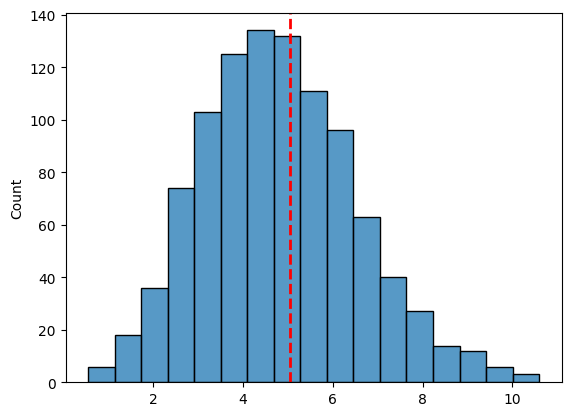

In [24]:
## Calculate the Population SD
pop_sd = statistics.pstdev(spend_n_save_df.num_apples)

pop_sd

## Turn into histogram
my_hist = sns.histplot(data=estimated_sds_with_n_minus_1, bins='scott')
my_hist.axvline(x=pop_sd, color='red', linestyle='--', linewidth=2)

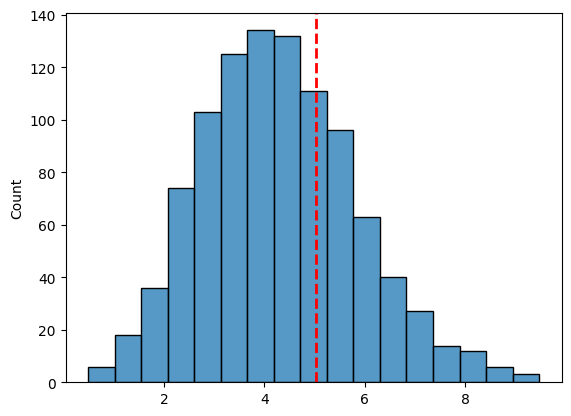

In [25]:
my_hist = sns.histplot(data=estimated_sds_with_n, bins='scott')
my_hist.axvline(x=pop_sd, color='red', linestyle='--', linewidth=2)